In [31]:
# --- CELL 1: Load UPDATED dataset with topics, communities & crossover ---

import os
import pandas as pd

ROOT = "/content/COMM557_Project"  # after the git clone you already ran
DATA_FILE = os.path.join(ROOT, "UPDATED_dataset_with_topics_communities_crossover.csv")

df = pd.read_csv(DATA_FILE)

print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist()[:40])  # first 40 just in case
df.head()

Shape: (4521, 31)
Columns:
['track_name', 'artist_name', 'danceability', 'energy', 'loudness', 'mode', 'key', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'tempo', 'time_signature', 'duration_ms', 'source', 'lyrics', 'lyrics_missing', 'topic_number', 'topic_label', 'community', 'label_short', 'label_long', 'category', 'community_simplified', 'label_short_simplified', 'label_long_simplified', 'category_simplified', 'track_type', 'is_cross', 'year', 'chart_longevity']


,track_name,artist_name,danceability,energy,loudness,mode,key,speechiness,acousticness,instrumentalness,...,label_long,category,community_simplified,label_short_simplified,label_long_simplified,category_simplified,track_type,is_cross,year,chart_longevity
0,Wow.,Post Malone,833.0,539.0,-7.399,0,11,178.0000,163.00,0.000002,...,Aggressive hype rap with braggadocio and expli...,Rap / Trap,0,Hype Rap / Flex,Aggressive hype rap with braggadocio and expli...,Rap / Trap,spotify,False,2019.0,sustained
1,Wow.,Post Malone,833.0,539.0,-7.399,0,11,178.0000,163.00,0.000002,...,Aggressive hype rap with braggadocio and expli...,Rap / Trap,0,Hype Rap / Flex,Aggressive hype rap with braggadocio and expli...,Rap / Trap,spotify,False,2020.0,sustained
2,"thank u, next",Ariana Grande,724.0,647.0,-5.642,1,1,0.0658,0.28,0.000000,...,NaN,NaN,Other,Other,Other,Other,spotify,False,2019.0,sustained
3,"thank u, next",Ariana Grande,724.0,647.0,-5.642,1,1,0.0658,0.28,0.000000,...,NaN,NaN,Other,Other,Other,Other,spotify,False,2020.0,sustained
4,Without Me,Halsey,752.0,488.0,-7.050,1,6,0.0705,297.00,0.000009,...,Gentle pop love songs with occasional Spanish ...,Pop,5,Soft Pop / Love,Gentle pop love songs with occasional Spanish ...,Pop,spotify,False,2019.0,sustained


In [33]:
# --- CELL 2: Normalize columns and detect community label + track type ---

import numpy as np

# Normalize column names to snake_case, lower
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
cols = set(df.columns)

print("[info] normalized columns:")
print(sorted(cols))

# 1) COMMUNITY / LYRICAL THEME LABEL
community_candidates = [
    "label_short_simplified",
    "label_short",
    "topic_label",
    "community_label",
    "community",
    "category",
]

label_col = None
for c in community_candidates:
    if c in cols:
        label_col = c
        break

if label_col is None:
    raise KeyError(
        "Could not find a community/label column. "
        "Looked for: " + ", ".join(community_candidates)
    )

print(f"[ok] Using community label column: {label_col}")

# 2) PLATFORM / TRACK-TYPE COLUMN (spotify / tiktok / cross)
track_type_col = None

# Prefer an already-baked track_type_fixed / track_type
for c in ["track_type_fixed", "track_type", "platform", "source"]:
    if c in cols:
        track_type_col = c
        break

# If we still didn't find one, see if we can build it from `source` + `is_cross`
if track_type_col is None and "source" in cols and "is_cross" in cols:
    print("[info] No track_type column, but found source + is_cross. Building track_type_fixed.")
    df["track_type_fixed"] = df["source"].astype(str).str.lower().str.strip()
    df.loc[df["is_cross"] == 1, "track_type_fixed"] = "cross"
    track_type_col = "track_type_fixed"

if track_type_col is None:
    raise KeyError(
        "Could not find a track-type column like 'track_type_fixed', 'track_type', "
        "'platform', or 'source', and could not build one."
    )

print(f"[ok] Using track-type column: {track_type_col}")

# Clean track_type values
df[track_type_col] = (
    df[track_type_col]
    .astype(str)
    .str.lower()
    .str.strip()
    .replace({
        "spotify-only": "spotify",
        "spotify_only": "spotify",
        "tiktok-only": "tiktok",
        "tiktok_only": "tiktok",
        "cross-over": "cross",
        "crossover": "cross",
        "both": "cross"
    })
)

print("\n[info] track-type distribution:")
print(df[track_type_col].value_counts(dropna=False))



[info] normalized columns:
['acousticness', 'artist_name', 'category', 'category_simplified', 'chart_longevity', 'community', 'community_simplified', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'is_cross', 'key', 'label_long', 'label_long_simplified', 'label_short', 'label_short_simplified', 'liveness', 'loudness', 'lyrics', 'lyrics_missing', 'mode', 'source', 'speechiness', 'tempo', 'time_signature', 'topic_label', 'topic_number', 'track_name', 'track_type', 'year']
[ok] Using community label column: label_short_simplified
[ok] Using track-type column: track_type

[info] track-type distribution:
track_type
spotify    3490
cross       541
tiktok      490
Name: count, dtype: int64


In [38]:
# --- NEW CELL 2b: Fix "Other" by falling back to original community labels ---

# Start from the simplified labels
df["label_fixed"] = df["label_short_simplified"]

# Identify rows labeled "Other" in the simplified scheme
mask_other = df["label_short_simplified"].str.lower() == "other"

# For those rows, fall back to the original network-based label_short
df.loc[mask_other, "label_fixed"] = df.loc[mask_other, "label_short"]

# Use this fixed label column for all RQ2 analysis
label_col = "label_fixed"

print("[info] label counts BEFORE fix (label_short_simplified):")
print(df["label_short_simplified"].value_counts().head(20))

print("\n[info] label counts AFTER fix (label_fixed):")
print(df["label_fixed"].value_counts().head(20))


[info] label counts BEFORE fix (label_short_simplified):
label_short_simplified
Other                            1372
Hype Rap / Flex                   351
Mainstream Pop                    306
Latin Pop (Emotional)             276
Soft Pop / Love                   256
Latin Trap / Urbano               253
Sad Pop / Breakup                 245
Romantic Ballads                  243
Global Trap / Hype                215
Latin Dance / Reggaeton           177
Romantic Reggaeton / Party        175
Melodic Trap                      149
Pop-R&B (Sensual)                 148
Alternative / Atmospheric Pop     140
Chant / Hook Pop                  122
Emo Rap / Melodic Hip-Hop          93
Name: count, dtype: int64

[info] label counts AFTER fix (label_fixed):
label_fixed
Hype Rap / Flex                  351
Mainstream Pop                   306
Latin Pop (Emotional)            276
Soft Pop / Love                  256
Latin Trap / Urbano              253
Sad Pop / Breakup                245
Romant

In [39]:
# --- CELL 3: Split of Spotify / TikTok / Cross within each community ---

valid_types = ["spotify", "tiktok", "cross"]
df_rq2 = df[df[track_type_col].isin(valid_types)].copy()

print(f"[info] rows kept for RQ2: {len(df_rq2)}")

# Counts per (community, track_type)
counts = (
    df_rq2
    .groupby([label_col, track_type_col])
    .size()
    .reset_index(name="n_songs")
)

# Percent within each community (row sums to 100)
total_per_comm = counts.groupby(label_col)["n_songs"].transform("sum")
counts["pct_within_comm"] = counts["n_songs"] / total_per_comm * 100

pivot_comm = (
    counts
    .pivot(index=label_col, columns=track_type_col, values="pct_within_comm")
    .fillna(0)
    .rename_axis(index="community", columns="track_type")
)

# Order communities by size (descending)
order = (
    counts.groupby(label_col)["n_songs"]
    .sum()
    .sort_values(ascending=False)
    .index
)
pivot_comm = pivot_comm.loc[order]

print("=== Split of Spotify / TikTok / Cross within each lyrical community (percent) ===")
pivot_comm.round(1)


[info] rows kept for RQ2: 4521
=== Split of Spotify / TikTok / Cross within each lyrical community (percent) ===


track_type,cross,spotify,tiktok
label_fixed,,,
Hype Rap / Flex,14.5,68.4,17.1
Mainstream Pop,13.7,77.5,8.8
Latin Pop (Emotional),10.5,83.3,6.2
Soft Pop / Love,8.2,83.6,8.2
Latin Trap / Urbano,22.9,67.6,9.5
Sad Pop / Breakup,7.3,80.0,12.7
Romantic Ballads,9.1,82.7,8.2
Global Trap / Hype,12.6,79.1,8.4
Latin Dance / Reggaeton,7.9,91.5,0.6


In [40]:
# --- CELL 4: Community composition within TikTok-crossover vs Spotify-only ---

# Keep only Spotify-only + Cross songs for this comparison
df_groups = df_rq2[df_rq2[track_type_col].isin(["spotify", "cross"])].copy()

group_counts = (
    df_groups
    .groupby([track_type_col, label_col])
    .size()
    .reset_index(name="n_songs")
)

# Percent of each community *within* each group (columns sum to 100)
total_per_group = group_counts.groupby(track_type_col)["n_songs"].transform("sum")
group_counts["pct_within_group"] = group_counts["n_songs"] / total_per_group * 100

pivot_group = (
    group_counts
    .pivot(index=label_col, columns=track_type_col, values="pct_within_group")
    .fillna(0)
    .rename_axis(index="community", columns="group")
)

# Keep communities in same order as earlier, but only those present
order_filtered = [c for c in order if c in pivot_group.index]
dropped = [c for c in order if c not in pivot_group.index]
if dropped:
    print("[info] communities dropped from RQ2 comparison (no spotify/cross songs):")
    print(dropped)

pivot_group = pivot_group.loc[order_filtered]

print("=== Lyrical community share within TikTok-crossover vs Spotify-only groups (percent) ===")
pivot_group.round(1)

=== Lyrical community share within TikTok-crossover vs Spotify-only groups (percent) ===


group,cross,spotify
community,,
Hype Rap / Flex,12.8,9.8
Mainstream Pop,10.6,9.7
Latin Pop (Emotional),7.3,9.4
Soft Pop / Love,5.3,8.8
Latin Trap / Urbano,14.6,7.0
Sad Pop / Breakup,4.5,8.0
Romantic Ballads,5.5,8.2
Global Trap / Hype,6.8,7.0
Latin Dance / Reggaeton,3.5,6.6


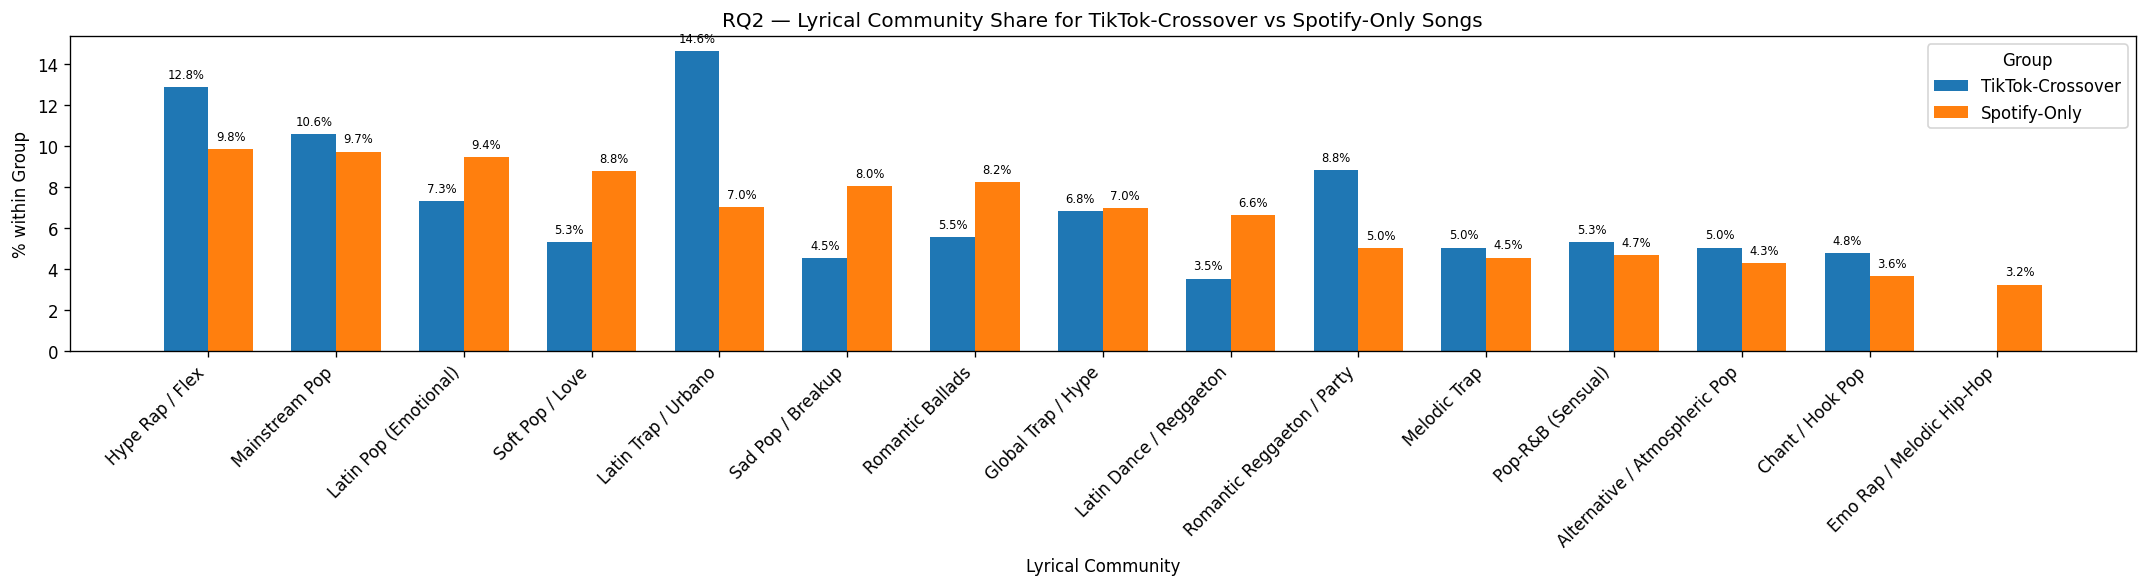

In [41]:
# --- CELL 5: Bar chart – RQ2 visualization ---

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 120

x = np.arange(len(pivot_group.index))
width = 0.35

# Get values safely
cross_vals = pivot_group["cross"].values if "cross" in pivot_group.columns else np.zeros(len(pivot_group))
spot_vals  = pivot_group["spotify"].values if "spotify" in pivot_group.columns else np.zeros(len(pivot_group))

plt.figure(figsize=(18, 5))

plt.bar(x - width/2, cross_vals, width, label="TikTok-Crossover")
plt.bar(x + width/2, spot_vals,  width, label="Spotify-Only")

# Add % labels above bars
for i, (cv, sv) in enumerate(zip(cross_vals, spot_vals)):
    if cv > 0:
        plt.text(x[i] - width/2, cv + 0.3, f"{cv:.1f}%", ha="center", va="bottom", fontsize=7)
    if sv > 0:
        plt.text(x[i] + width/2, sv + 0.3, f"{sv:.1f}%", ha="center", va="bottom", fontsize=7)

plt.xticks(x, pivot_group.index, rotation=45, ha="right")
plt.ylabel("% within Group")
plt.xlabel("Lyrical Community")
plt.title("RQ2 — Lyrical Community Share for TikTok-Crossover vs Spotify-Only Songs")
plt.legend(title="Group")
plt.tight_layout()
plt.show()


In [42]:
# --- CELL 6: Top communities per group (for writeup / slides) ---

cross_series = pivot_group["cross"] if "cross" in pivot_group.columns else pd.Series(0, index=pivot_group.index)
spot_series  = pivot_group["spotify"] if "spotify" in pivot_group.columns else pd.Series(0, index=pivot_group.index)

top_cross = cross_series.sort_values(ascending=False).head(5)
top_spot  = spot_series.sort_values(ascending=False).head(5)

print("Top communities among TikTok-crossover songs:")
print(top_cross.round(1))

print("\nTop communities among Spotify-only songs:")
print(top_spot.round(1))


Top communities among TikTok-crossover songs:
community
Latin Trap / Urbano           14.6
Hype Rap / Flex               12.8
Mainstream Pop                10.6
Romantic Reggaeton / Party     8.8
Latin Pop (Emotional)          7.3
Name: cross, dtype: float64

Top communities among Spotify-only songs:
community
Hype Rap / Flex          9.8
Mainstream Pop           9.7
Latin Pop (Emotional)    9.4
Soft Pop / Love          8.8
Romantic Ballads         8.2
Name: spotify, dtype: float64
